In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is not enabled.")
    print("Go to Runtime → Change runtime type → T4 GPU.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q --upgrade transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 78.7 MB/s eta 0:00:00


In [3]:
import os
import gc
import json
import time
import copy
import random
import zipfile
import glob
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Subset

import torchvision.transforms as transforms
from torchvision.datasets import CIFAR100

from transformers import (
    AutoImageProcessor,
    SwinForImageClassification
)

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Random seed:", SEED)
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Random seed: 42
Device: cuda
GPU: Tesla T4


In [5]:
IMAGE_SIZE = 224
NUM_CLASSES = 100

BATCH_SIZE = 32
PRETRAINED_EPOCHS = 5
SCRATCH_EPOCHS = 5

PRETRAINED_LEARNING_RATE = 2e-5
SCRATCH_LEARNING_RATE = 0.001

TRAIN_SIZE = 45000
VALIDATION_SIZE = 5000

NUM_WORKERS = 2

TINY_MODEL_ID = "microsoft/swin-tiny-patch4-window7-224"
SMALL_MODEL_ID = "microsoft/swin-small-patch4-window7-224"

USE_MIXED_PRECISION = device.type == "cuda"

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Pretrained epochs:", PRETRAINED_EPOCHS)
print("Scratch epochs:", SCRATCH_EPOCHS)
print("Pretrained learning rate:", PRETRAINED_LEARNING_RATE)
print("Scratch learning rate:", SCRATCH_LEARNING_RATE)
print("Mixed precision:", USE_MIXED_PRECISION)

Image size: 224
Batch size: 32
Pretrained epochs: 5
Scratch epochs: 5
Pretrained learning rate: 2e-05
Scratch learning rate: 0.001
Mixed precision: True


In [6]:
image_processor = AutoImageProcessor.from_pretrained(
    TINY_MODEL_ID
)

IMAGE_MEAN = image_processor.image_mean
IMAGE_STD = image_processor.image_std

print("Processor size:", image_processor.size)
print("Image mean:", IMAGE_MEAN)
print("Image standard deviation:", IMAGE_STD)

preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Processor size: SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None)
Image mean: (0.485, 0.456, 0.406)
Image standard deviation: (0.229, 0.224, 0.225)


In [7]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGE_MEAN,
        std=IMAGE_STD
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGE_MEAN,
        std=IMAGE_STD
    )
])

In [8]:
DATA_DIRECTORY = "/content/data"

augmented_training_dataset = CIFAR100(
    root=DATA_DIRECTORY,
    train=True,
    transform=train_transform,
    download=True
)

evaluation_training_dataset = CIFAR100(
    root=DATA_DIRECTORY,
    train=True,
    transform=evaluation_transform,
    download=True
)

test_dataset = CIFAR100(
    root=DATA_DIRECTORY,
    train=False,
    transform=evaluation_transform,
    download=True
)

split_generator = torch.Generator().manual_seed(SEED)

all_indices = torch.randperm(
    len(augmented_training_dataset),
    generator=split_generator
).tolist()

train_indices = all_indices[:TRAIN_SIZE]

validation_indices = all_indices[
    TRAIN_SIZE:TRAIN_SIZE + VALIDATION_SIZE
]

train_dataset = Subset(
    augmented_training_dataset,
    train_indices
)

validation_dataset = Subset(
    evaluation_training_dataset,
    validation_indices
)

class_names = test_dataset.classes

print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Test images:", len(test_dataset))
print("Number of classes:", len(class_names))

100%|██████████| 169M/169M [44:49<00:00, 62.8kB/s]


Training images: 45000
Validation images: 5000
Test images: 10000
Number of classes: 100


In [9]:
loader_arguments = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda"
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_arguments
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_arguments
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_arguments
)

sample_images, sample_labels = next(iter(train_loader))

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Minimum label:", sample_labels.min().item())
print("Maximum label:", sample_labels.max().item())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Minimum label: 2
Maximum label: 97


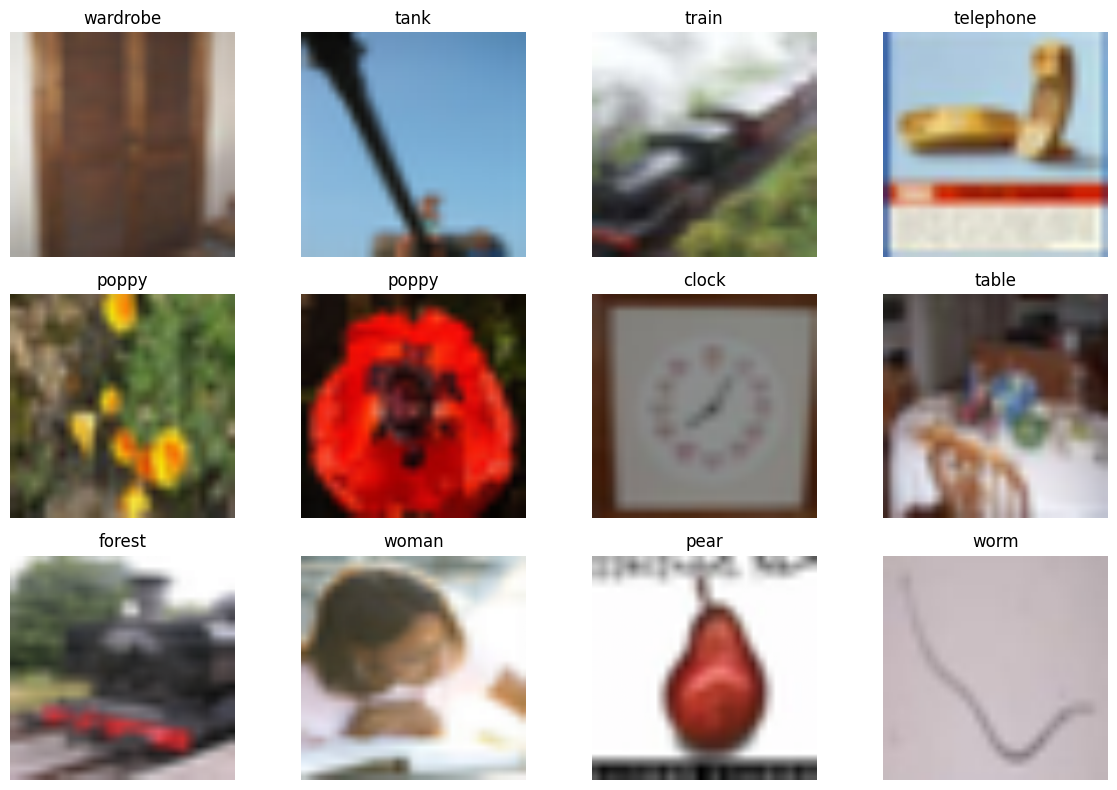

In [10]:
def unnormalize_image(image):
    mean_tensor = torch.tensor(
        IMAGE_MEAN
    ).view(3, 1, 1)

    std_tensor = torch.tensor(
        IMAGE_STD
    ).view(3, 1, 1)

    image = image.cpu() * std_tensor + mean_tensor
    return torch.clamp(image, 0, 1)


images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for index in range(12):
    plt.subplot(3, 4, index + 1)

    displayed_image = unnormalize_image(
        images[index]
    )

    displayed_image = displayed_image.permute(
        1, 2, 0
    )

    plt.imshow(displayed_image)
    plt.title(class_names[labels[index].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
def count_total_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
    )


def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def estimate_fp32_model_size_mb(model):
    bytes_per_parameter = 4

    total_bytes = (
        count_total_parameters(model)
        * bytes_per_parameter
    )

    return total_bytes / (1024 ** 2)

In [12]:
def extract_logits(model_output):
    if hasattr(model_output, "logits"):
        return model_output.logits

    return model_output

In [13]:
def create_gradient_scaler():
    if device.type != "cuda":
        return None

    try:
        return torch.amp.GradScaler(
            "cuda",
            enabled=USE_MIXED_PRECISION
        )
    except AttributeError:
        return torch.cuda.amp.GradScaler(
            enabled=USE_MIXED_PRECISION
        )

In [14]:
def train_one_epoch(
    model,
    data_loader,
    loss_function,
    optimizer,
    scaler,
    freeze_huggingface_backbone=False
):
    model.train()

    # The assignment requires that only the pretrained
    # classification head be trained.
    if (
        freeze_huggingface_backbone
        and hasattr(model, "swin")
    ):
        model.swin.eval()

    running_loss = 0.0
    running_correct = 0
    total_examples = 0

    for images, labels in data_loader:
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        autocast_context = (
            torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=True
            )
            if USE_MIXED_PRECISION
            else nullcontext()
        )

        with autocast_context:
            outputs = model(images)
            logits = extract_logits(outputs)
            loss = loss_function(logits, labels)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size

        running_correct += (
            logits.argmax(dim=1) == labels
        ).sum().item()

        total_examples += batch_size

    average_loss = running_loss / total_examples

    accuracy = (
        100.0
        * running_correct
        / total_examples
    )

    return average_loss, accuracy

In [15]:
@torch.inference_mode()
def evaluate_model(
    model,
    data_loader,
    loss_function
):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total_examples = 0

    for images, labels in data_loader:
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        autocast_context = (
            torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=True
            )
            if USE_MIXED_PRECISION
            else nullcontext()
        )

        with autocast_context:
            outputs = model(images)
            logits = extract_logits(outputs)
            loss = loss_function(logits, labels)

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size

        running_correct += (
            logits.argmax(dim=1) == labels
        ).sum().item()

        total_examples += batch_size

    average_loss = running_loss / total_examples

    accuracy = (
        100.0
        * running_correct
        / total_examples
    )

    return average_loss, accuracy

In [16]:
def copy_trainable_state_to_cpu(model):
    return {
        name: parameter.detach().cpu().clone()
        for name, parameter in model.named_parameters()
        if parameter.requires_grad
    }


def restore_trainable_state(model, saved_state):
    named_parameters = dict(
        model.named_parameters()
    )

    with torch.no_grad():
        for name, saved_parameter in saved_state.items():
            named_parameters[name].copy_(
                saved_parameter.to(
                    named_parameters[name].device
                )
            )

In [17]:
def train_complete_model(
    model,
    model_name,
    number_of_epochs,
    learning_rate,
    freeze_huggingface_backbone=False
):
    model = model.to(device)

    loss_function = nn.CrossEntropyLoss()

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    if len(trainable_parameters) == 0:
        raise ValueError(
            "The model has no trainable parameters."
        )

    optimizer = torch.optim.Adam(
        trainable_parameters,
        lr=learning_rate
    )

    scaler = create_gradient_scaler()

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": [],
        "epoch_time_seconds": []
    }

    best_validation_accuracy = -1.0
    best_trainable_state = None

    print("=" * 80)
    print("Training:", model_name)
    print("Epochs:", number_of_epochs)
    print("Learning rate:", learning_rate)
    print(
        "Total parameters:",
        f"{count_total_parameters(model):,}"
    )
    print(
        "Trainable parameters:",
        f"{count_trainable_parameters(model):,}"
    )
    print("=" * 80)

    for epoch in range(number_of_epochs):
        if device.type == "cuda":
            torch.cuda.synchronize()

        epoch_start_time = time.perf_counter()

        train_loss, train_accuracy = train_one_epoch(
            model=model,
            data_loader=train_loader,
            loss_function=loss_function,
            optimizer=optimizer,
            scaler=scaler,
            freeze_huggingface_backbone=(
                freeze_huggingface_backbone
            )
        )

        validation_loss, validation_accuracy = (
            evaluate_model(
                model=model,
                data_loader=validation_loader,
                loss_function=loss_function
            )
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        epoch_time = (
            time.perf_counter()
            - epoch_start_time
        )

        history["train_loss"].append(
            float(train_loss)
        )

        history["train_accuracy"].append(
            float(train_accuracy)
        )

        history["validation_loss"].append(
            float(validation_loss)
        )

        history["validation_accuracy"].append(
            float(validation_accuracy)
        )

        history["epoch_time_seconds"].append(
            float(epoch_time)
        )

        if (
            validation_accuracy
            > best_validation_accuracy
        ):
            best_validation_accuracy = (
                validation_accuracy
            )

            best_trainable_state = (
                copy_trainable_state_to_cpu(model)
            )

        print(
            f"Epoch {epoch + 1:02d}/{number_of_epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train accuracy: {train_accuracy:.2f}% | "
            f"Validation loss: {validation_loss:.4f} | "
            f"Validation accuracy: "
            f"{validation_accuracy:.2f}% | "
            f"Time: {epoch_time:.2f} seconds"
        )

    if best_trainable_state is not None:
        restore_trainable_state(
            model,
            best_trainable_state
        )

    test_loss, test_accuracy = evaluate_model(
        model=model,
        data_loader=test_loader,
        loss_function=loss_function
    )

    average_epoch_time = float(
        np.mean(history["epoch_time_seconds"])
    )

    total_training_time = float(
        np.sum(history["epoch_time_seconds"])
    )

    checkpoint_path = (
        f"/content/{model_name}_best_trainable_weights.pth"
    )

    torch.save(
        {
            "model_name": model_name,
            "trainable_state_dict": (
                best_trainable_state
            )
        },
        checkpoint_path
    )

    print("-" * 80)
    print(
        "Best validation accuracy:",
        f"{best_validation_accuracy:.2f}%"
    )
    print("Test loss:", f"{test_loss:.4f}")
    print(
        "Test accuracy:",
        f"{test_accuracy:.2f}%"
    )
    print(
        "Average time per epoch:",
        f"{average_epoch_time:.2f} seconds"
    )
    print(
        "Total training time:",
        f"{total_training_time:.2f} seconds"
    )
    print("Checkpoint:", checkpoint_path)

    metrics = {
        "best_validation_accuracy": float(
            best_validation_accuracy
        ),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy),
        "average_epoch_time_seconds": (
            average_epoch_time
        ),
        "total_training_time_seconds": (
            total_training_time
        )
    }

    return model, history, metrics

In [18]:
all_results = []
all_histories = {}

In [19]:
id2label = {
    index: label
    for index, label in enumerate(class_names)
}

label2id = {
    label: index
    for index, label in enumerate(class_names)
}


def build_frozen_pretrained_swin(model_id):
    model = SwinForImageClassification.from_pretrained(
        model_id,
        num_labels=NUM_CLASSES,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    # Freeze every parameter first.
    for parameter in model.parameters():
        parameter.requires_grad = False

    # Unfreeze only the new CIFAR-100 classifier.
    for parameter in model.classifier.parameters():
        parameter.requires_grad = True

    return model

In [20]:
verification_model = build_frozen_pretrained_swin(
    TINY_MODEL_ID
)

print(
    "Total parameters:",
    f"{count_total_parameters(verification_model):,}"
)

print(
    "Trainable parameters:",
    f"{count_trainable_parameters(verification_model):,}"
)

print("\nTrainable parameter names:")

for name, parameter in verification_model.named_parameters():
    if parameter.requires_grad:
        print(name, tuple(parameter.shape))

del verification_model
gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Total parameters: 27,596,254
Trainable parameters: 76,900

Trainable parameter names:
classifier.weight (100, 768)
classifier.bias (100,)


In [22]:
swin_tiny_model = build_frozen_pretrained_swin(
    TINY_MODEL_ID
)

tiny_total_parameters = count_total_parameters(
    swin_tiny_model
)

tiny_trainable_parameters = (
    count_trainable_parameters(swin_tiny_model)
)

tiny_model_size_mb = estimate_fp32_model_size_mb(
    swin_tiny_model
)

trained_tiny, tiny_history, tiny_metrics = (
    train_complete_model(
        model=swin_tiny_model,
        model_name="Pretrained_Swin_Tiny",
        number_of_epochs=PRETRAINED_EPOCHS,
        learning_rate=PRETRAINED_LEARNING_RATE,
        freeze_huggingface_backbone=True
    )
)

all_histories["Pretrained_Swin_Tiny"] = (
    tiny_history
)

all_results.append({
    "Model": "Pretrained_Swin_Tiny",
    "Training Method": (
        "Pretrained backbone; classifier only"
    ),
    "Epochs": PRETRAINED_EPOCHS,
    "Batch Size": BATCH_SIZE,
    "Learning Rate": (
        PRETRAINED_LEARNING_RATE
    ),
    "Total Parameters": tiny_total_parameters,
    "Trainable Parameters": (
        tiny_trainable_parameters
    ),
    "Parameters (Millions)": (
        tiny_total_parameters / 1e6
    ),
    "Trainable Parameters (Millions)": (
        tiny_trainable_parameters / 1e6
    ),
    "Estimated FP32 Size (MB)": (
        tiny_model_size_mb
    ),
    "Best Validation Accuracy (%)": (
        tiny_metrics[
            "best_validation_accuracy"
        ]
    ),
    "Test Accuracy (%)": (
        tiny_metrics["test_accuracy"]
    ),
    "Test Loss": tiny_metrics["test_loss"],
    "Average Time per Epoch (s)": (
        tiny_metrics[
            "average_epoch_time_seconds"
        ]
    ),
    "Total Training Time (s)": (
        tiny_metrics[
            "total_training_time_seconds"
        ]
    )
})

pd.DataFrame(all_results).to_csv(
    "/content/problem2_partial_results.csv",
    index=False
)

with open(
    "/content/problem2_partial_histories.json",
    "w"
) as file:
    json.dump(
        all_histories,
        file,
        indent=4
    )

del trained_tiny
del swin_tiny_model

gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()

print("Swin-Tiny results saved.")

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Training: Pretrained_Swin_Tiny
Epochs: 5
Learning rate: 2e-05
Total parameters: 27,596,254
Trainable parameters: 76,900
Epoch 01/5 | Train loss: 4.0866 | Train accuracy: 23.11% | Validation loss: 3.5704 | Validation accuracy: 45.58% | Time: 116.28 seconds
Epoch 02/5 | Train loss: 3.1567 | Train accuracy: 52.56% | Validation loss: 2.7809 | Validation accuracy: 57.82% | Time: 117.30 seconds
Epoch 03/5 | Train loss: 2.4981 | Train accuracy: 60.00% | Validation loss: 2.2390 | Validation accuracy: 62.10% | Time: 117.90 seconds
Epoch 04/5 | Train loss: 2.0560 | Train accuracy: 63.61% | Validation loss: 1.8857 | Validation accuracy: 64.56% | Time: 121.27 seconds
Epoch 05/5 | Train loss: 1.7700 | Train accuracy: 65.53% | Validation loss: 1.6547 | Validation accuracy: 65.90% | Time: 120.77 seconds
--------------------------------------------------------------------------------
Best validation accuracy: 65.90%
Test loss: 1.6792
Test accuracy: 65.87%
Average time per epoch: 118.70 seconds
Total t

In [23]:
swin_small_model = build_frozen_pretrained_swin(
    SMALL_MODEL_ID
)

small_total_parameters = count_total_parameters(
    swin_small_model
)

small_trainable_parameters = (
    count_trainable_parameters(swin_small_model)
)

small_model_size_mb = estimate_fp32_model_size_mb(
    swin_small_model
)

trained_small, small_history, small_metrics = (
    train_complete_model(
        model=swin_small_model,
        model_name="Pretrained_Swin_Small",
        number_of_epochs=PRETRAINED_EPOCHS,
        learning_rate=PRETRAINED_LEARNING_RATE,
        freeze_huggingface_backbone=True
    )
)

all_histories["Pretrained_Swin_Small"] = (
    small_history
)

all_results.append({
    "Model": "Pretrained_Swin_Small",
    "Training Method": (
        "Pretrained backbone; classifier only"
    ),
    "Epochs": PRETRAINED_EPOCHS,
    "Batch Size": BATCH_SIZE,
    "Learning Rate": (
        PRETRAINED_LEARNING_RATE
    ),
    "Total Parameters": small_total_parameters,
    "Trainable Parameters": (
        small_trainable_parameters
    ),
    "Parameters (Millions)": (
        small_total_parameters / 1e6
    ),
    "Trainable Parameters (Millions)": (
        small_trainable_parameters / 1e6
    ),
    "Estimated FP32 Size (MB)": (
        small_model_size_mb
    ),
    "Best Validation Accuracy (%)": (
        small_metrics[
            "best_validation_accuracy"
        ]
    ),
    "Test Accuracy (%)": (
        small_metrics["test_accuracy"]
    ),
    "Test Loss": small_metrics["test_loss"],
    "Average Time per Epoch (s)": (
        small_metrics[
            "average_epoch_time_seconds"
        ]
    ),
    "Total Training Time (s)": (
        small_metrics[
            "total_training_time_seconds"
        ]
    )
})

pd.DataFrame(all_results).to_csv(
    "/content/problem2_partial_results.csv",
    index=False
)

with open(
    "/content/problem2_partial_histories.json",
    "w"
) as file:
    json.dump(
        all_histories,
        file,
        indent=4
    )

del trained_small
del swin_small_model

gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()

print("Swin-Small results saved.")

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin:   0%|          | 0.00/199M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Training: Pretrained_Swin_Small
Epochs: 5
Learning rate: 2e-05
Total parameters: 48,914,158
Trainable parameters: 76,900


model.safetensors:   0%|          | 0.00/199M [00:00<?, ?B/s]

Epoch 01/5 | Train loss: 4.0399 | Train accuracy: 25.83% | Validation loss: 3.4742 | Validation accuracy: 49.04% | Time: 167.70 seconds
Epoch 02/5 | Train loss: 3.0262 | Train accuracy: 55.92% | Validation loss: 2.6251 | Validation accuracy: 61.46% | Time: 166.02 seconds
Epoch 03/5 | Train loss: 2.3238 | Train accuracy: 63.15% | Validation loss: 2.0613 | Validation accuracy: 65.26% | Time: 169.29 seconds
Epoch 04/5 | Train loss: 1.8748 | Train accuracy: 66.30% | Validation loss: 1.7093 | Validation accuracy: 67.74% | Time: 166.31 seconds
Epoch 05/5 | Train loss: 1.5911 | Train accuracy: 68.09% | Validation loss: 1.4883 | Validation accuracy: 69.34% | Time: 164.97 seconds
--------------------------------------------------------------------------------
Best validation accuracy: 69.34%
Test loss: 1.4847
Test accuracy: 69.31%
Average time per epoch: 166.86 seconds
Total training time: 834.28 seconds
Checkpoint: /content/Pretrained_Swin_Small_best_trainable_weights.pth
Swin-Small results sa

In [24]:
def window_partition(x, window_size):
    """
    Input:
        x: [batch, height, width, channels]

    Output:
        windows:
        [batch * number_of_windows,
         window_size,
         window_size,
         channels]
    """

    batch_size, height, width, channels = x.shape

    x = x.view(
        batch_size,
        height // window_size,
        window_size,
        width // window_size,
        window_size,
        channels
    )

    windows = x.permute(
        0, 1, 3, 2, 4, 5
    ).contiguous()

    windows = windows.view(
        -1,
        window_size,
        window_size,
        channels
    )

    return windows


def window_reverse(
    windows,
    window_size,
    height,
    width
):
    """
    Reconstruct the feature map from windows.
    """

    number_of_windows_per_image = (
        height // window_size
    ) * (
        width // window_size
    )

    batch_size = (
        windows.shape[0]
        // number_of_windows_per_image
    )

    x = windows.view(
        batch_size,
        height // window_size,
        width // window_size,
        window_size,
        window_size,
        -1
    )

    x = x.permute(
        0, 1, 3, 2, 4, 5
    ).contiguous()

    x = x.view(
        batch_size,
        height,
        width,
        -1
    )

    return x

In [25]:
class SwinMLP(nn.Module):
    def __init__(
        self,
        input_dimension,
        hidden_dimension,
        dropout=0.0
    ):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(
                input_dimension,
                hidden_dimension
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                hidden_dimension,
                input_dimension
            ),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.layers(x)

In [26]:
class WindowAttention(nn.Module):
    def __init__(
        self,
        dimension,
        window_size,
        number_of_heads,
        qkv_bias=True,
        attention_dropout=0.0,
        projection_dropout=0.0
    ):
        super().__init__()

        if dimension % number_of_heads != 0:
            raise ValueError(
                "Dimension must be divisible by "
                "the number of heads."
            )

        self.dimension = dimension
        self.window_size = window_size
        self.number_of_heads = number_of_heads

        head_dimension = (
            dimension // number_of_heads
        )

        self.scale = head_dimension ** -0.5

        number_of_relative_positions = (
            2 * window_size - 1
        ) ** 2

        self.relative_position_bias_table = (
            nn.Parameter(
                torch.zeros(
                    number_of_relative_positions,
                    number_of_heads
                )
            )
        )

        coordinates_height = torch.arange(
            window_size
        )

        coordinates_width = torch.arange(
            window_size
        )

        coordinate_grid = torch.stack(
            torch.meshgrid(
                coordinates_height,
                coordinates_width,
                indexing="ij"
            )
        )

        flattened_coordinates = (
            coordinate_grid.flatten(1)
        )

        relative_coordinates = (
            flattened_coordinates[:, :, None]
            - flattened_coordinates[:, None, :]
        )

        relative_coordinates = (
            relative_coordinates.permute(
                1, 2, 0
            ).contiguous()
        )

        relative_coordinates[:, :, 0] += (
            window_size - 1
        )

        relative_coordinates[:, :, 1] += (
            window_size - 1
        )

        relative_coordinates[:, :, 0] *= (
            2 * window_size - 1
        )

        relative_position_index = (
            relative_coordinates.sum(-1)
        )

        self.register_buffer(
            "relative_position_index",
            relative_position_index,
            persistent=False
        )

        self.qkv = nn.Linear(
            dimension,
            dimension * 3,
            bias=qkv_bias
        )

        self.attention_dropout = nn.Dropout(
            attention_dropout
        )

        self.projection = nn.Linear(
            dimension,
            dimension
        )

        self.projection_dropout = nn.Dropout(
            projection_dropout
        )

        nn.init.trunc_normal_(
            self.relative_position_bias_table,
            std=0.02
        )

    def forward(self, x, attention_mask=None):
        batch_windows, tokens, channels = x.shape

        qkv = self.qkv(x)

        qkv = qkv.reshape(
            batch_windows,
            tokens,
            3,
            self.number_of_heads,
            channels // self.number_of_heads
        )

        qkv = qkv.permute(
            2, 0, 3, 1, 4
        )

        query, key, value = (
            qkv[0],
            qkv[1],
            qkv[2]
        )

        query = query * self.scale

        attention = (
            query @ key.transpose(-2, -1)
        )

        relative_position_bias = (
            self.relative_position_bias_table[
                self.relative_position_index.view(-1)
            ]
        )

        relative_position_bias = (
            relative_position_bias.view(
                tokens,
                tokens,
                self.number_of_heads
            )
        )

        relative_position_bias = (
            relative_position_bias.permute(
                2, 0, 1
            ).contiguous()
        )

        attention = (
            attention
            + relative_position_bias.unsqueeze(0)
        )

        if attention_mask is not None:
            number_of_windows = (
                attention_mask.shape[0]
            )

            attention = attention.view(
                batch_windows // number_of_windows,
                number_of_windows,
                self.number_of_heads,
                tokens,
                tokens
            )

            attention = (
                attention
                + attention_mask.unsqueeze(0).unsqueeze(2)
            )

            attention = attention.view(
                -1,
                self.number_of_heads,
                tokens,
                tokens
            )

        attention = F.softmax(
            attention,
            dim=-1
        )

        attention = self.attention_dropout(
            attention
        )

        output = attention @ value

        output = output.transpose(
            1, 2
        ).reshape(
            batch_windows,
            tokens,
            channels
        )

        output = self.projection(output)
        output = self.projection_dropout(output)

        return output

In [27]:
class SwinTransformerBlock(nn.Module):
    def __init__(
        self,
        dimension,
        input_resolution,
        number_of_heads,
        window_size=7,
        shift_size=0,
        mlp_ratio=4.0,
        dropout=0.0,
        attention_dropout=0.0
    ):
        super().__init__()

        self.dimension = dimension
        self.input_resolution = input_resolution

        height, width = input_resolution

        if min(height, width) <= window_size:
            window_size = min(height, width)
            shift_size = 0

        if shift_size >= window_size:
            raise ValueError(
                "Shift size must be smaller than "
                "window size."
            )

        self.window_size = window_size
        self.shift_size = shift_size

        self.normalization_1 = nn.LayerNorm(
            dimension
        )

        self.attention = WindowAttention(
            dimension=dimension,
            window_size=window_size,
            number_of_heads=number_of_heads,
            qkv_bias=True,
            attention_dropout=attention_dropout,
            projection_dropout=dropout
        )

        self.normalization_2 = nn.LayerNorm(
            dimension
        )

        hidden_dimension = int(
            dimension * mlp_ratio
        )

        self.mlp = SwinMLP(
            input_dimension=dimension,
            hidden_dimension=hidden_dimension,
            dropout=dropout
        )

        attention_mask = self.create_attention_mask()

        if attention_mask is not None:
            self.register_buffer(
                "attention_mask",
                attention_mask,
                persistent=False
            )
        else:
            self.attention_mask = None

    def create_attention_mask(self):
        if self.shift_size == 0:
            return None

        height, width = self.input_resolution

        image_mask = torch.zeros(
            1,
            height,
            width,
            1
        )

        height_slices = (
            slice(0, -self.window_size),
            slice(
                -self.window_size,
                -self.shift_size
            ),
            slice(-self.shift_size, None)
        )

        width_slices = (
            slice(0, -self.window_size),
            slice(
                -self.window_size,
                -self.shift_size
            ),
            slice(-self.shift_size, None)
        )

        region_number = 0

        for height_slice in height_slices:
            for width_slice in width_slices:
                image_mask[
                    :,
                    height_slice,
                    width_slice,
                    :
                ] = region_number

                region_number += 1

        mask_windows = window_partition(
            image_mask,
            self.window_size
        )

        mask_windows = mask_windows.view(
            -1,
            self.window_size * self.window_size
        )

        attention_mask = (
            mask_windows.unsqueeze(1)
            - mask_windows.unsqueeze(2)
        )

        attention_mask = attention_mask.masked_fill(
            attention_mask != 0,
            float(-100.0)
        )

        attention_mask = attention_mask.masked_fill(
            attention_mask == 0,
            float(0.0)
        )

        return attention_mask

    def forward(self, x):
        height, width = self.input_resolution

        batch_size, sequence_length, channels = (
            x.shape
        )

        if sequence_length != height * width:
            raise ValueError(
                "The input token count does not match "
                "the expected feature-map resolution."
            )

        shortcut = x

        x = self.normalization_1(x)

        x = x.view(
            batch_size,
            height,
            width,
            channels
        )

        if self.shift_size > 0:
            shifted_x = torch.roll(
                x,
                shifts=(
                    -self.shift_size,
                    -self.shift_size
                ),
                dims=(1, 2)
            )
        else:
            shifted_x = x

        x_windows = window_partition(
            shifted_x,
            self.window_size
        )

        x_windows = x_windows.view(
            -1,
            self.window_size * self.window_size,
            channels
        )

        attended_windows = self.attention(
            x_windows,
            attention_mask=self.attention_mask
        )

        attended_windows = attended_windows.view(
            -1,
            self.window_size,
            self.window_size,
            channels
        )

        shifted_x = window_reverse(
            windows=attended_windows,
            window_size=self.window_size,
            height=height,
            width=width
        )

        if self.shift_size > 0:
            x = torch.roll(
                shifted_x,
                shifts=(
                    self.shift_size,
                    self.shift_size
                ),
                dims=(1, 2)
            )
        else:
            x = shifted_x

        x = x.view(
            batch_size,
            height * width,
            channels
        )

        x = shortcut + x

        x = x + self.mlp(
            self.normalization_2(x)
        )

        return x

In [28]:
class PatchMerging(nn.Module):
    def __init__(
        self,
        input_resolution,
        dimension
    ):
        super().__init__()

        self.input_resolution = input_resolution
        self.dimension = dimension

        self.normalization = nn.LayerNorm(
            4 * dimension
        )

        self.reduction = nn.Linear(
            4 * dimension,
            2 * dimension,
            bias=False
        )

    def forward(self, x):
        height, width = self.input_resolution

        batch_size, sequence_length, channels = (
            x.shape
        )

        if sequence_length != height * width:
            raise ValueError(
                "Patch-merging input has an "
                "unexpected sequence length."
            )

        if height % 2 != 0 or width % 2 != 0:
            raise ValueError(
                "Patch merging requires even height "
                "and width."
            )

        x = x.view(
            batch_size,
            height,
            width,
            channels
        )

        top_left = x[:, 0::2, 0::2, :]
        bottom_left = x[:, 1::2, 0::2, :]
        top_right = x[:, 0::2, 1::2, :]
        bottom_right = x[:, 1::2, 1::2, :]

        x = torch.cat(
            [
                top_left,
                bottom_left,
                top_right,
                bottom_right
            ],
            dim=-1
        )

        x = x.view(
            batch_size,
            -1,
            4 * channels
        )

        x = self.normalization(x)
        x = self.reduction(x)

        return x

In [29]:
class SwinStage(nn.Module):
    def __init__(
        self,
        dimension,
        input_resolution,
        depth,
        number_of_heads,
        window_size,
        mlp_ratio=4.0,
        dropout=0.0,
        attention_dropout=0.0,
        downsample=True
    ):
        super().__init__()

        blocks = []

        for block_index in range(depth):
            shift_size = (
                0
                if block_index % 2 == 0
                else window_size // 2
            )

            blocks.append(
                SwinTransformerBlock(
                    dimension=dimension,
                    input_resolution=input_resolution,
                    number_of_heads=number_of_heads,
                    window_size=window_size,
                    shift_size=shift_size,
                    mlp_ratio=mlp_ratio,
                    dropout=dropout,
                    attention_dropout=(
                        attention_dropout
                    )
                )
            )

        self.blocks = nn.ModuleList(blocks)

        if downsample:
            self.downsample = PatchMerging(
                input_resolution=input_resolution,
                dimension=dimension
            )
        else:
            self.downsample = None

    def forward(self, x):
        for block in self.blocks:
            x = block(x)

        if self.downsample is not None:
            x = self.downsample(x)

        return x

In [30]:
class ScratchSwinTransformer(nn.Module):
    def __init__(
        self,
        image_size=224,
        patch_size=4,
        input_channels=3,
        number_of_classes=100,
        embedding_dimension=48,
        stage_depths=(2, 2, 2, 2),
        stage_heads=(3, 6, 12, 24),
        window_size=7,
        mlp_ratio=4.0,
        dropout=0.0,
        attention_dropout=0.0
    ):
        super().__init__()

        if image_size % patch_size != 0:
            raise ValueError(
                "Image size must be divisible by "
                "patch size."
            )

        if len(stage_depths) != 4:
            raise ValueError(
                "This implementation expects four stages."
            )

        if len(stage_heads) != 4:
            raise ValueError(
                "This implementation expects four "
                "head settings."
            )

        self.image_size = image_size
        self.patch_size = patch_size

        self.patch_embedding = nn.Conv2d(
            in_channels=input_channels,
            out_channels=embedding_dimension,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.patch_normalization = nn.LayerNorm(
            embedding_dimension
        )

        patch_resolution = (
            image_size // patch_size
        )

        stage_resolutions = [
            (
                patch_resolution,
                patch_resolution
            ),
            (
                patch_resolution // 2,
                patch_resolution // 2
            ),
            (
                patch_resolution // 4,
                patch_resolution // 4
            ),
            (
                patch_resolution // 8,
                patch_resolution // 8
            )
        ]

        stage_dimensions = [
            embedding_dimension,
            embedding_dimension * 2,
            embedding_dimension * 4,
            embedding_dimension * 8
        ]

        self.stages = nn.ModuleList()

        for stage_index in range(4):
            self.stages.append(
                SwinStage(
                    dimension=stage_dimensions[
                        stage_index
                    ],
                    input_resolution=stage_resolutions[
                        stage_index
                    ],
                    depth=stage_depths[
                        stage_index
                    ],
                    number_of_heads=stage_heads[
                        stage_index
                    ],
                    window_size=window_size,
                    mlp_ratio=mlp_ratio,
                    dropout=dropout,
                    attention_dropout=(
                        attention_dropout
                    ),
                    downsample=(
                        stage_index < 3
                    )
                )
            )

        final_dimension = stage_dimensions[-1]

        self.final_normalization = nn.LayerNorm(
            final_dimension
        )

        self.classification_head = nn.Linear(
            final_dimension,
            number_of_classes
        )

        self.apply(self.initialize_weights)

    @staticmethod
    def initialize_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(
                module.weight,
                std=0.02
            )

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Conv2d):
            nn.init.trunc_normal_(
                module.weight,
                std=0.02
            )

            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, images):
        x = self.patch_embedding(images)

        # [B, C, H, W] → [B, H*W, C]
        x = x.flatten(2).transpose(1, 2)

        x = self.patch_normalization(x)

        for stage in self.stages:
            x = stage(x)

        x = self.final_normalization(x)

        # Global average pooling across tokens.
        x = x.mean(dim=1)

        logits = self.classification_head(x)

        return logits

In [31]:
scratch_verification_model = (
    ScratchSwinTransformer(
        image_size=IMAGE_SIZE,
        patch_size=4,
        input_channels=3,
        number_of_classes=NUM_CLASSES,
        embedding_dimension=48,
        stage_depths=(2, 2, 2, 2),
        stage_heads=(3, 6, 12, 24),
        window_size=7,
        mlp_ratio=4.0,
        dropout=0.0,
        attention_dropout=0.0
    )
).to(device)

dummy_images = torch.randn(
    2,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=device
)

with torch.no_grad():
    dummy_logits = scratch_verification_model(
        dummy_images
    )

print("Input shape:", dummy_images.shape)
print("Output shape:", dummy_logits.shape)

print(
    "Total parameters:",
    f"{count_total_parameters(scratch_verification_model):,}"
)

print(
    "Trainable parameters:",
    f"{count_trainable_parameters(scratch_verification_model):,}"
)

del scratch_verification_model
del dummy_images
del dummy_logits

gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()

Input shape: torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 100])
Total parameters: 5,165,566
Trainable parameters: 5,165,566


In [32]:
scratch_swin_model = ScratchSwinTransformer(
    image_size=IMAGE_SIZE,
    patch_size=4,
    input_channels=3,
    number_of_classes=NUM_CLASSES,
    embedding_dimension=48,
    stage_depths=(2, 2, 2, 2),
    stage_heads=(3, 6, 12, 24),
    window_size=7,
    mlp_ratio=4.0,
    dropout=0.0,
    attention_dropout=0.0
)

scratch_total_parameters = (
    count_total_parameters(scratch_swin_model)
)

scratch_trainable_parameters = (
    count_trainable_parameters(
        scratch_swin_model
    )
)

scratch_model_size_mb = (
    estimate_fp32_model_size_mb(
        scratch_swin_model
    )
)

trained_scratch, scratch_history, scratch_metrics = (
    train_complete_model(
        model=scratch_swin_model,
        model_name="Scratch_Swin",
        number_of_epochs=SCRATCH_EPOCHS,
        learning_rate=SCRATCH_LEARNING_RATE,
        freeze_huggingface_backbone=False
    )
)

all_histories["Scratch_Swin"] = scratch_history

all_results.append({
    "Model": "Scratch_Swin",
    "Training Method": (
        "Random initialization; full model"
    ),
    "Epochs": SCRATCH_EPOCHS,
    "Batch Size": BATCH_SIZE,
    "Learning Rate": SCRATCH_LEARNING_RATE,
    "Total Parameters": (
        scratch_total_parameters
    ),
    "Trainable Parameters": (
        scratch_trainable_parameters
    ),
    "Parameters (Millions)": (
        scratch_total_parameters / 1e6
    ),
    "Trainable Parameters (Millions)": (
        scratch_trainable_parameters / 1e6
    ),
    "Estimated FP32 Size (MB)": (
        scratch_model_size_mb
    ),
    "Best Validation Accuracy (%)": (
        scratch_metrics[
            "best_validation_accuracy"
        ]
    ),
    "Test Accuracy (%)": (
        scratch_metrics["test_accuracy"]
    ),
    "Test Loss": scratch_metrics[
        "test_loss"
    ],
    "Average Time per Epoch (s)": (
        scratch_metrics[
            "average_epoch_time_seconds"
        ]
    ),
    "Total Training Time (s)": (
        scratch_metrics[
            "total_training_time_seconds"
        ]
    )
})

del trained_scratch
del scratch_swin_model

gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()

print("Scratch Swin training is complete.")

Training: Scratch_Swin
Epochs: 5
Learning rate: 0.001
Total parameters: 5,165,566
Trainable parameters: 5,165,566
Epoch 01/5 | Train loss: 4.4395 | Train accuracy: 3.08% | Validation loss: 4.4908 | Validation accuracy: 2.20% | Time: 154.04 seconds
Epoch 02/5 | Train loss: 4.5066 | Train accuracy: 2.46% | Validation loss: 4.6207 | Validation accuracy: 1.28% | Time: 153.17 seconds
Epoch 03/5 | Train loss: 4.5101 | Train accuracy: 2.40% | Validation loss: 4.4244 | Validation accuracy: 3.92% | Time: 154.36 seconds
Epoch 04/5 | Train loss: 4.5269 | Train accuracy: 2.14% | Validation loss: 4.5096 | Validation accuracy: 2.18% | Time: 153.17 seconds
Epoch 05/5 | Train loss: 4.4385 | Train accuracy: 3.18% | Validation loss: 4.3931 | Validation accuracy: 3.96% | Time: 157.69 seconds
--------------------------------------------------------------------------------
Best validation accuracy: 3.96%
Test loss: 4.3956
Test accuracy: 3.83%
Average time per epoch: 154.48 seconds
Total training time: 772.

In [33]:
results_dataframe = pd.DataFrame(
    all_results
)

results_dataframe = results_dataframe.sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

results_dataframe.to_csv(
    "/content/problem2_final_results.csv",
    index=False
)

with open(
    "/content/problem2_all_histories.json",
    "w"
) as file:
    json.dump(
        all_histories,
        file,
        indent=4
    )

results_dataframe

,Model,Training Method,Epochs,Batch Size,Learning Rate,Total Parameters,Trainable Parameters,Parameters (Millions),Trainable Parameters (Millions),Estimated FP32 Size (MB),Best Validation Accuracy (%),Test Accuracy (%),Test Loss,Average Time per Epoch (s),Total Training Time (s)
0,Pretrained_Swin_Small,Pretrained backbone; classifier only,5,32,0.00002,48914158,76900,48.914158,0.076900,186.592705,69.34,69.31,1.484665,166.856178,834.280892
1,Pretrained_Swin_Tiny,Pretrained backbone; classifier only,5,32,0.00002,27596254,76900,27.596254,0.076900,105.271355,65.90,65.87,1.679154,118.703393,593.516966
2,Scratch_Swin,Random initialization; full model,5,32,0.00100,5165566,5165566,5.165566,5.165566,19.705070,3.96,3.83,4.395574,154.484662,772.423309


In [34]:
report_columns = [
    "Model",
    "Training Method",
    "Total Parameters",
    "Trainable Parameters",
    "Parameters (Millions)",
    "Estimated FP32 Size (MB)",
    "Average Time per Epoch (s)",
    "Total Training Time (s)",
    "Best Validation Accuracy (%)",
    "Test Accuracy (%)"
]

report_table = results_dataframe[
    report_columns
].copy()

report_table.to_csv(
    "/content/problem2_report_table.csv",
    index=False
)

report_table

,Model,Training Method,Total Parameters,Trainable Parameters,Parameters (Millions),Estimated FP32 Size (MB),Average Time per Epoch (s),Total Training Time (s),Best Validation Accuracy (%),Test Accuracy (%)
0,Pretrained_Swin_Small,Pretrained backbone; classifier only,48914158,76900,48.914158,186.592705,166.856178,834.280892,69.34,69.31
1,Pretrained_Swin_Tiny,Pretrained backbone; classifier only,27596254,76900,27.596254,105.271355,118.703393,593.516966,65.90,65.87
2,Scratch_Swin,Random initialization; full model,5165566,5165566,5.165566,19.705070,154.484662,772.423309,3.96,3.83


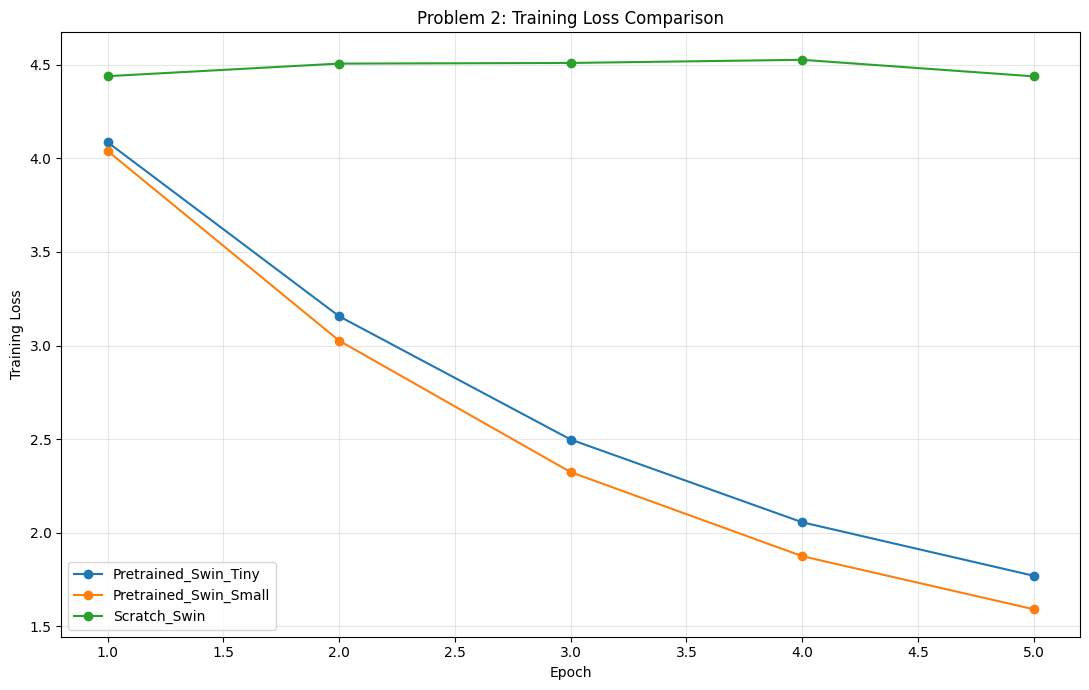

In [35]:
plt.figure(figsize=(11, 7))

for model_name, history in all_histories.items():
    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Problem 2: Training Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem2_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

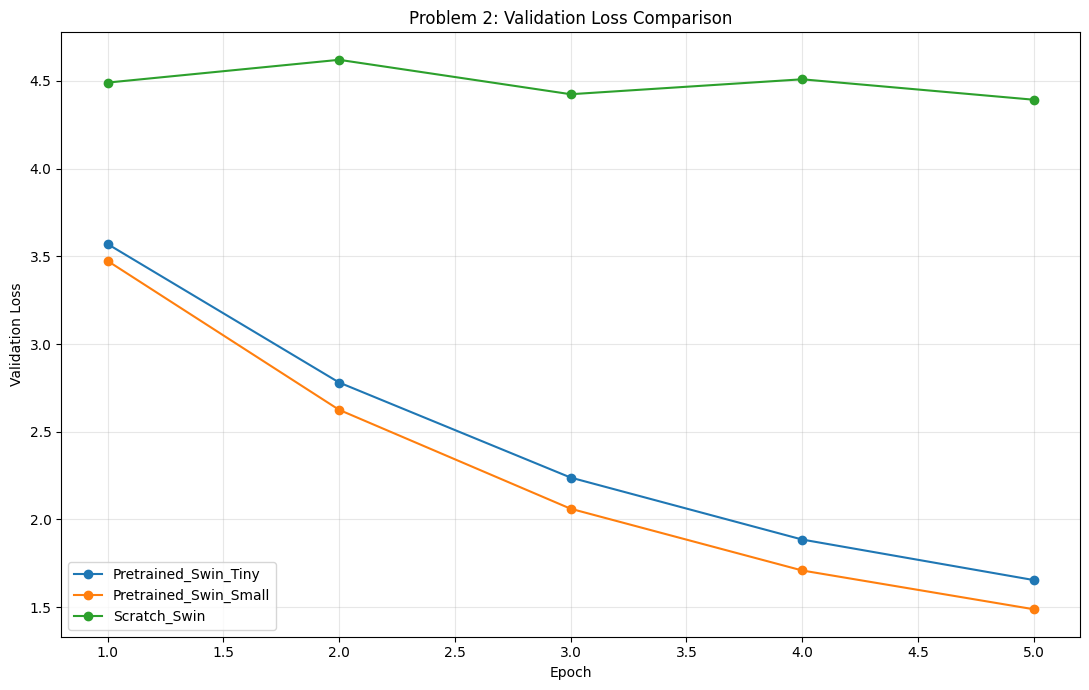

In [36]:
plt.figure(figsize=(11, 7))

for model_name, history in all_histories.items():
    epochs = range(
        1,
        len(history["validation_loss"]) + 1
    )

    plt.plot(
        epochs,
        history["validation_loss"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Problem 2: Validation Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem2_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

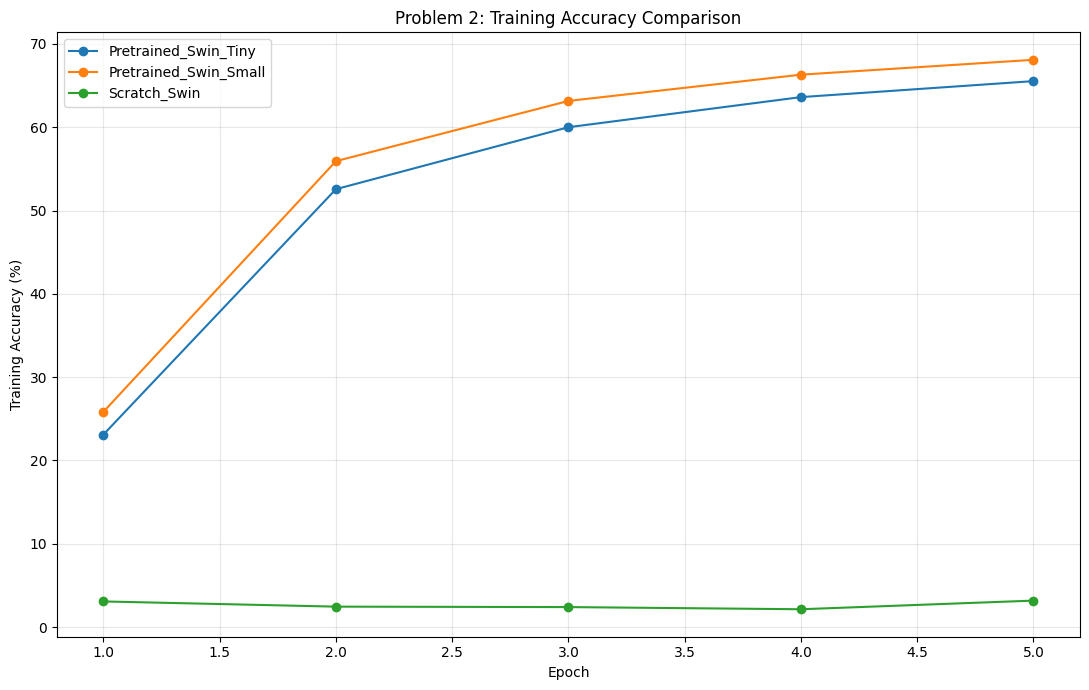

In [37]:
plt.figure(figsize=(11, 7))

for model_name, history in all_histories.items():
    epochs = range(
        1,
        len(history["train_accuracy"]) + 1
    )

    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Problem 2: Training Accuracy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem2_training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

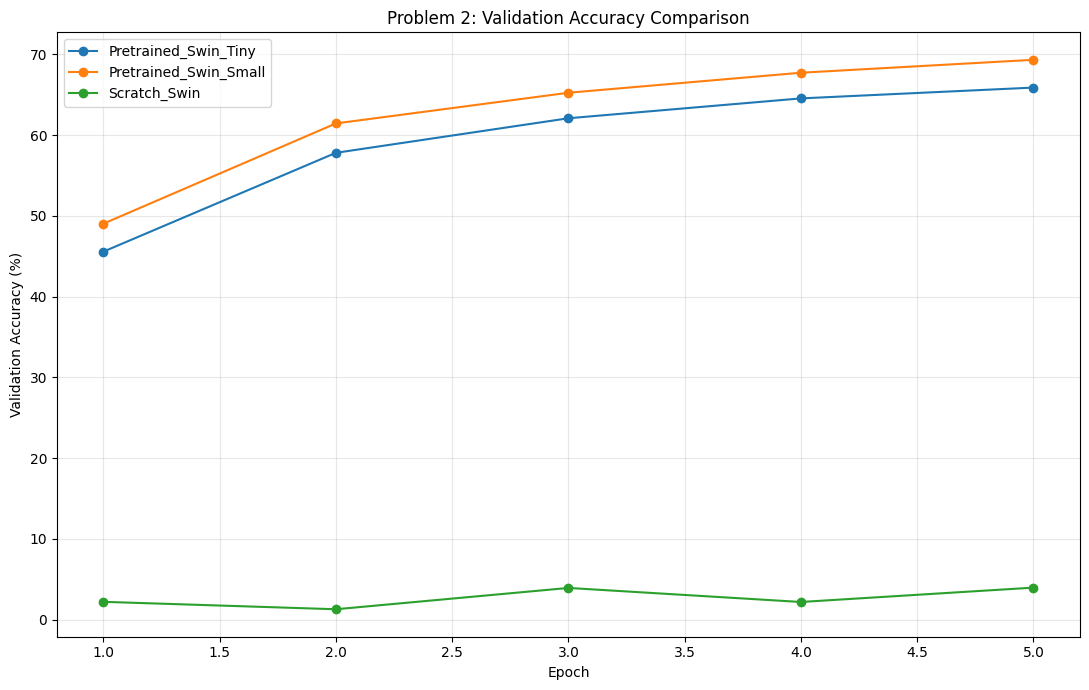

In [38]:
plt.figure(figsize=(11, 7))

for model_name, history in all_histories.items():
    epochs = range(
        1,
        len(history["validation_accuracy"]) + 1
    )

    plt.plot(
        epochs,
        history["validation_accuracy"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Problem 2: Validation Accuracy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem2_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

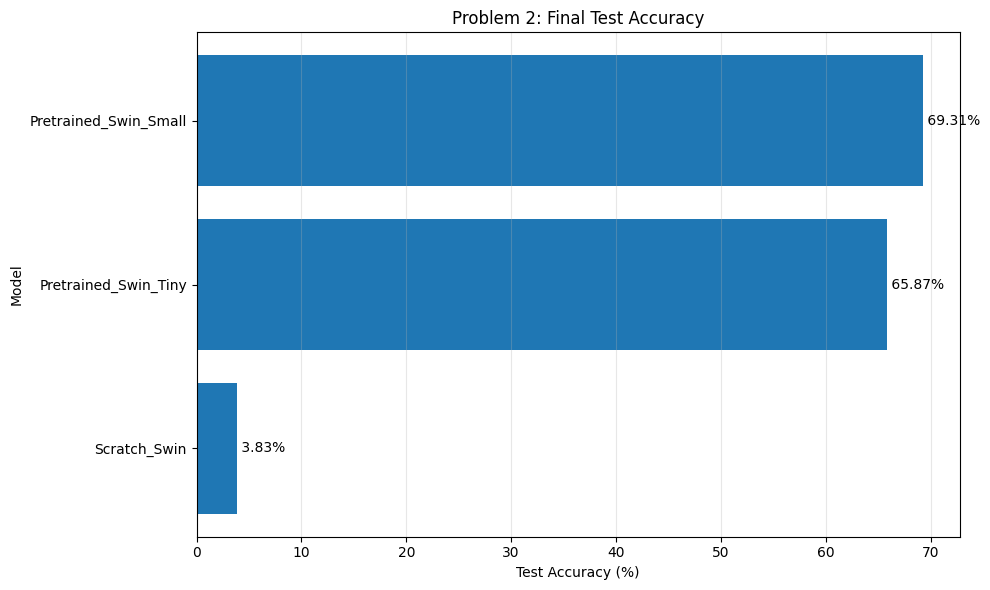

In [39]:
accuracy_data = results_dataframe.sort_values(
    by="Test Accuracy (%)",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    accuracy_data["Model"],
    accuracy_data["Test Accuracy (%)"]
)

plt.xlabel("Test Accuracy (%)")
plt.ylabel("Model")
plt.title("Problem 2: Final Test Accuracy")
plt.grid(axis="x", alpha=0.3)

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2f}%",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "/content/problem2_test_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

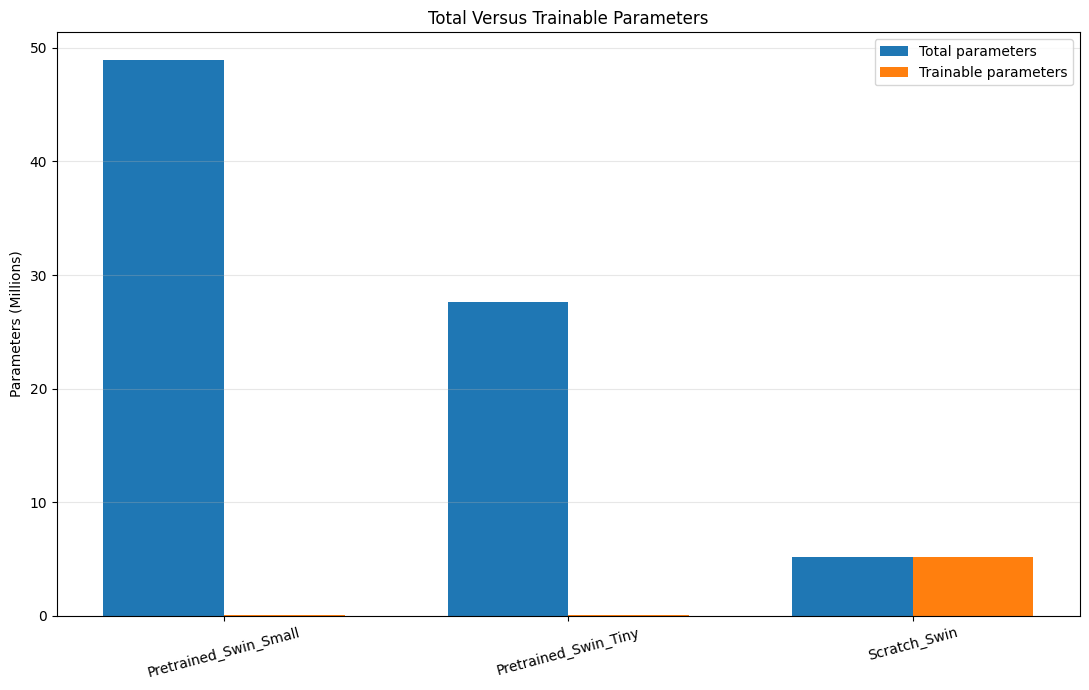

In [40]:
parameter_data = results_dataframe.copy()

x_positions = np.arange(
    len(parameter_data)
)

bar_width = 0.35

plt.figure(figsize=(11, 7))

plt.bar(
    x_positions - bar_width / 2,
    parameter_data["Parameters (Millions)"],
    width=bar_width,
    label="Total parameters"
)

plt.bar(
    x_positions + bar_width / 2,
    parameter_data[
        "Trainable Parameters (Millions)"
    ],
    width=bar_width,
    label="Trainable parameters"
)

plt.xticks(
    x_positions,
    parameter_data["Model"],
    rotation=15
)

plt.ylabel("Parameters (Millions)")
plt.title("Total Versus Trainable Parameters")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem2_parameter_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

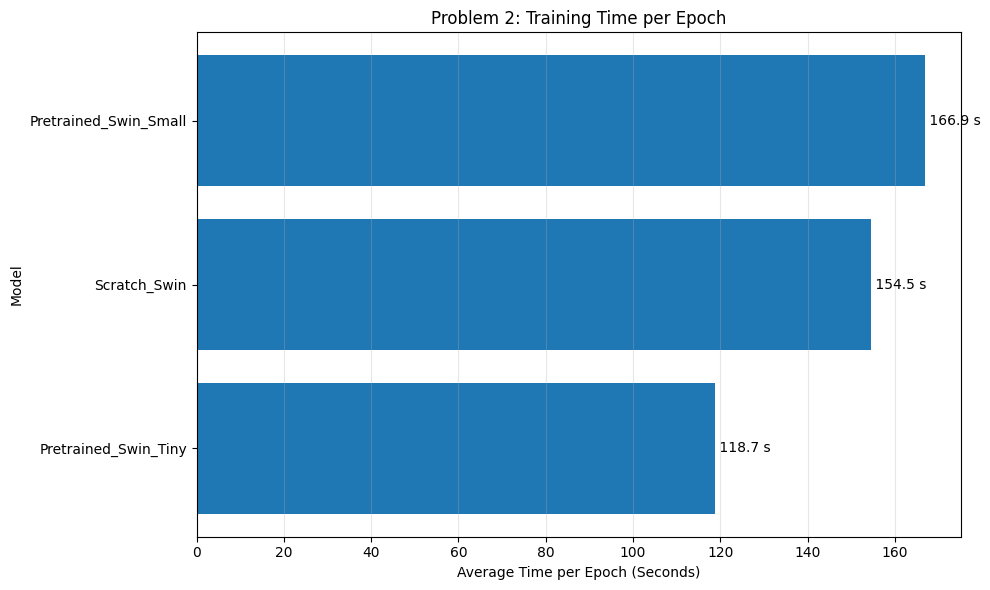

In [41]:
time_data = results_dataframe.sort_values(
    by="Average Time per Epoch (s)",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    time_data["Model"],
    time_data["Average Time per Epoch (s)"]
)

plt.xlabel("Average Time per Epoch (Seconds)")
plt.ylabel("Model")
plt.title("Problem 2: Training Time per Epoch")
plt.grid(axis="x", alpha=0.3)

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.1f} s",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "/content/problem2_epoch_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

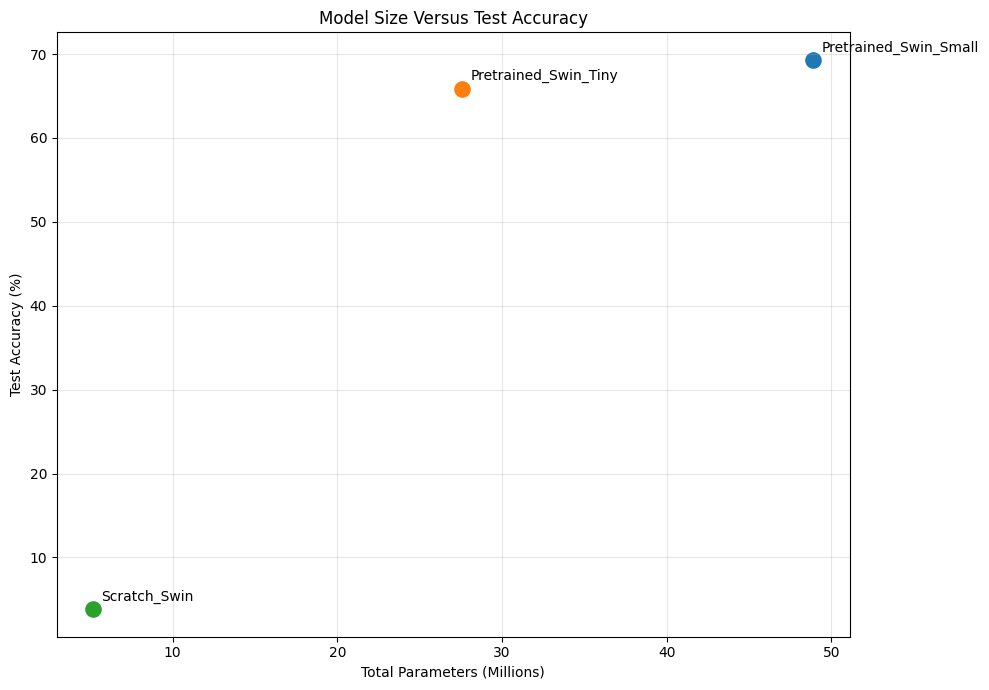

In [42]:
plt.figure(figsize=(10, 7))

for _, row in results_dataframe.iterrows():
    plt.scatter(
        row["Parameters (Millions)"],
        row["Test Accuracy (%)"],
        s=120
    )

    plt.annotate(
        row["Model"],
        (
            row["Parameters (Millions)"],
            row["Test Accuracy (%)"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Total Parameters (Millions)")
plt.ylabel("Test Accuracy (%)")
plt.title("Model Size Versus Test Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem2_size_vs_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

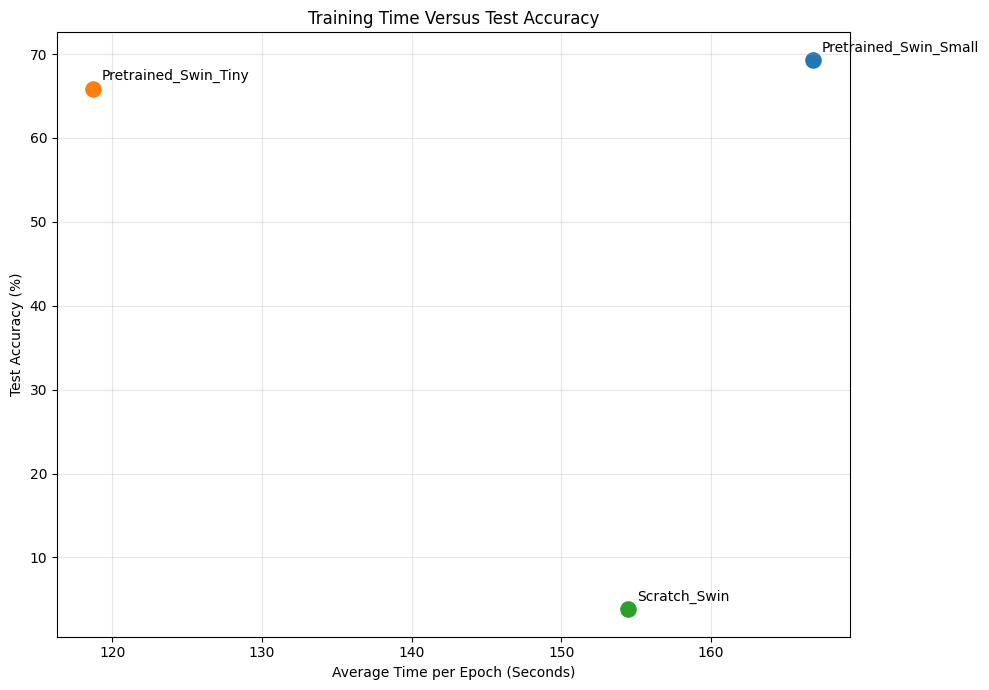

In [43]:
plt.figure(figsize=(10, 7))

for _, row in results_dataframe.iterrows():
    plt.scatter(
        row["Average Time per Epoch (s)"],
        row["Test Accuracy (%)"],
        s=120
    )

    plt.annotate(
        row["Model"],
        (
            row["Average Time per Epoch (s)"],
            row["Test Accuracy (%)"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Average Time per Epoch (Seconds)")
plt.ylabel("Test Accuracy (%)")
plt.title("Training Time Versus Test Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem2_time_vs_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
files_to_include = []

files_to_include.extend(
    glob.glob("/content/problem2_*.csv")
)

files_to_include.extend(
    glob.glob("/content/problem2_*.json")
)

files_to_include.extend(
    glob.glob("/content/problem2_*.png")
)

files_to_include.extend(
    glob.glob(
        "/content/*_best_trainable_weights.pth"
    )
)

zip_path = "/content/HW5_Problem2_Outputs.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for file_path in files_to_include:
        zip_file.write(
            file_path,
            arcname=os.path.basename(file_path)
        )

print("ZIP created:", zip_path)
print("\nFiles included:")

for file_path in files_to_include:
    print("-", os.path.basename(file_path))

ZIP created: /content/HW5_Problem2_Outputs.zip

Files included:
- problem2_partial_results.csv
- problem2_report_table.csv
- problem2_final_results.csv
- problem2_partial_histories.json
- problem2_all_histories.json
- problem2_time_vs_accuracy.png
- problem2_test_accuracy.png
- problem2_size_vs_accuracy.png
- problem2_parameter_comparison.png
- problem2_validation_accuracy.png
- problem2_validation_loss.png
- problem2_epoch_time.png
- problem2_training_loss.png
- problem2_training_accuracy.png
- Pretrained_Swin_Small_best_trainable_weights.pth
- Pretrained_Swin_Tiny_best_trainable_weights.pth
- Scratch_Swin_best_trainable_weights.pth


In [45]:
from google.colab import files

files.download(
    "/content/HW5_Problem2_Outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>